# Root Locus Design

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import control as ct
import control.matlab as cmat
import cmath 

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## Topic 11 Design Example 2

In [4]:
# define Plant
num = 4**2
den = np.convolve([1, 0],[1, 2*0.5*4, 4**2])
G = ct.tf(num,den)

# Basic Control
K_proportional = 2
# Loop Gain L
L = K_proportional*G
Gcl_proportional=ct.feedback(L,1)
scl_proportional = Gcl_proportional.poles()
s_ol = G.poles()

cm.show_tf_latex(G,show=True)

<IPython.core.display.Math object>

In [5]:
# Target poles 
# 
wn = 2*np.abs(s_ol[0])
zeta = 0.7
s_target = complex(-zeta * wn, wn*np.sqrt(1-zeta**2))
cm.pretty_row_print(s_target,"Target pole location: ")

Target pole location:  (-5.60 + 5.71i)

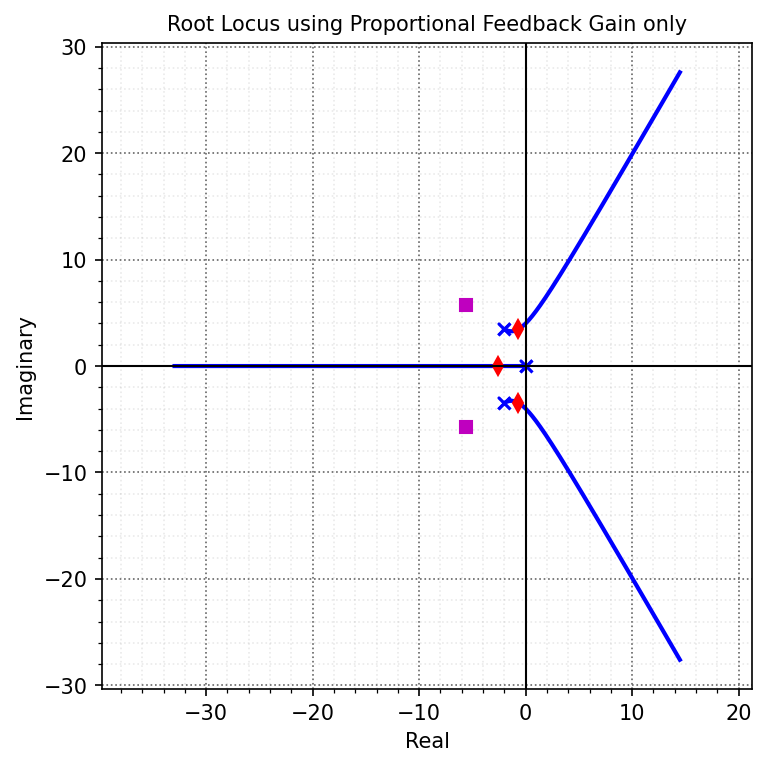

In [ ]:
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist = cm.Root_Locus_gains(L)
r_proportional = ct.rlocus(L,gains=klist,xlim = (-5,5),ylim=(-5,5),ax=ax,color='b')
plt.plot(scl_proportional.real,scl_proportional.imag,'rd')
ax.plot(s_target.real,s_target.imag,'ms')
ax.plot(s_target.real,-s_target.imag,'ms')
ax.axis('equal')
ax.set_ylim(-10,10)
ax.set_xlim(-15,1)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')
cm.new_pzmap(ax,G,'Root Locus')
plt.title("Root Locus using Proportional Feedback Gain only")
bm.nicegrid(ax)
plt.savefig("./figs/L11_des2_0.pdf", dpi=600)
plt.show()

omega_n:	2.749
zeta   :	0.408
Tr     :	0.52s
Ts     :	4.97s
Mp     :	0.25
Tp     :	1.25s
Yss    :	1.00


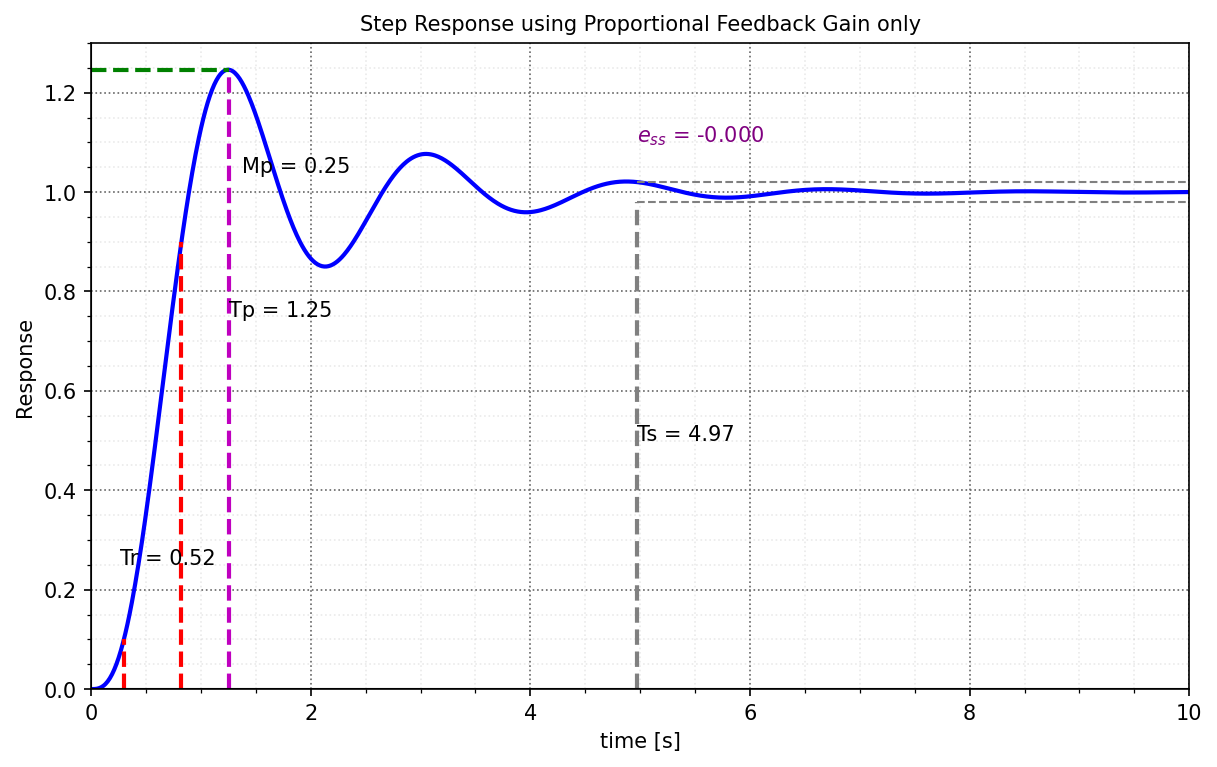

In [7]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
t = np.linspace(0,10,1000)
y_proportional, t = cmat.step(Gcl_proportional,T=t)
S = cm.Step_info(t,y_proportional)
S.printout()
S.nice_plot(ax)
plt.title("Step Response using Proportional Feedback Gain only")
bm.nicegrid(ax)
plt.savefig("./figs/L11_des2_0a.pdf", dpi=600)
plt.show()

In [8]:
z_comp = 0.5*abs(s_target.real) # to the left of the target pole locations to 
                                # avoid trapping the pole on the real line to the right of the dominant poles
phi_z = cmath.phase(s_target + z_comp)*180/np.pi
Gpoles = G.poles()
Gzeros = G.zeros()

N = 2 # Double Lead
phi_p = N*phi_z - sum([cmath.phase(x) for x in (s_target - Gpoles)])*180/np.pi
p_comp = - s_target.real + s_target.imag/-np.tan(np.mod((-180.0-phi_p)/N,360.0)*np.pi/180.0)
Gc = ct.tf([1, z_comp],[1, p_comp])
Gc = Gc**N

L_lead = G * Gc
Kc = 1/abs(L_lead(s_target))
print(f"{Kc = : 5.3f}")
print(f"{z_comp = : 5.3f}")
print(f"{p_comp = : 5.3f}")
Gc *= Kc
L_lead *= Kc

cm.show_tf_latex(Gc,r"G_c(s)",show=True,factor=True,sigfigs=3)
cm.write_tf_latex(Gc, source+"Gc_11_17.tex", label="G_c(s)", factor=True, sigfigs=3, inline=True)


Kc =  662.311
z_comp =  2.800
p_comp =  40.938


<IPython.core.display.Math object>

In [9]:
Gcl_lead = ct.feedback(L_lead,1)
scl_lead = Gcl_lead.poles()
print("Frequency of closed looop poles",np.abs(scl_lead))

Frequency of closed looop poles [  54.625   18.786    8.000    8.000    1.265]



Found break-in/out at K = -0.000
At possible locations s = -40.938


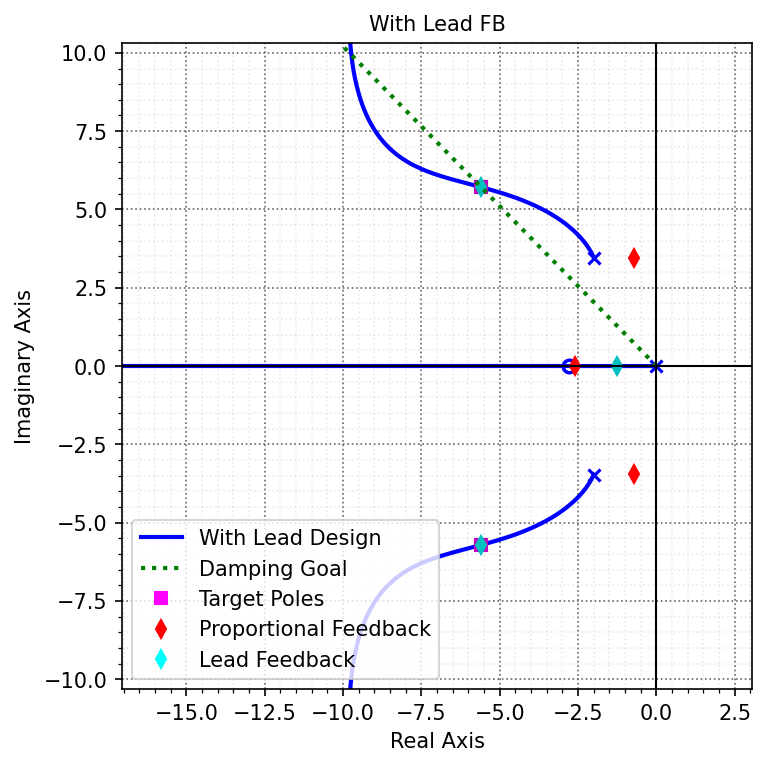

In [10]:
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist = cm.Root_Locus_gains(L_lead)
r_new = ct.rlocus(L_lead,gains=klist,xlim = (-60,10), ylim=(-35,35), ax=ax,color='b')
ax.plot(s_target.real,s_target.imag,'ms')
ax.plot(s_target.real,-s_target.imag,'ms')
plt.plot(scl_proportional.real,scl_proportional.imag,'rd')
plt.plot(scl_lead.real,scl_lead.imag,'cd')
th = np.cos(zeta)
plt.plot([0,-10*zeta*wn],[0,10*wn*np.sqrt(1-zeta**2)],'g:')
ax.axis('equal')
ax.set_xlim(-15,1)
ax.set_ylim(-10,10)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')
bm.nicegrid(ax)
plt.title("Root Locus using Lead Feedback Gain")
ax.set_title('With Lead FB')
if 1:
    # Create custom legend handles
    custom_lines = [
        Line2D([0], [0], color='blue', lw=2, linestyle='-'),
        Line2D([0], [0], color='g', lw=2, linestyle=':'),
    #    Line2D([0], [0], color='c', lw=2, linestyle='--'),
        Line2D([0], [0], color='magenta', marker='s', linestyle='None', markersize=6),
        Line2D([0], [0], color='red', marker='d', linestyle='None', markersize=6),
        Line2D([0], [0], color='cyan', marker='d', linestyle='None', markersize=6)
    ]
    # Add legend with custom handles
    ax.legend(custom_lines, ['With Lead Design', 'Damping Goal', 'Target Poles', 'Proportional Feedback', 'Lead Feedback'], loc=3)

plt.savefig("./figs/L11_des2_1.pdf", dpi=600)
plt.show()

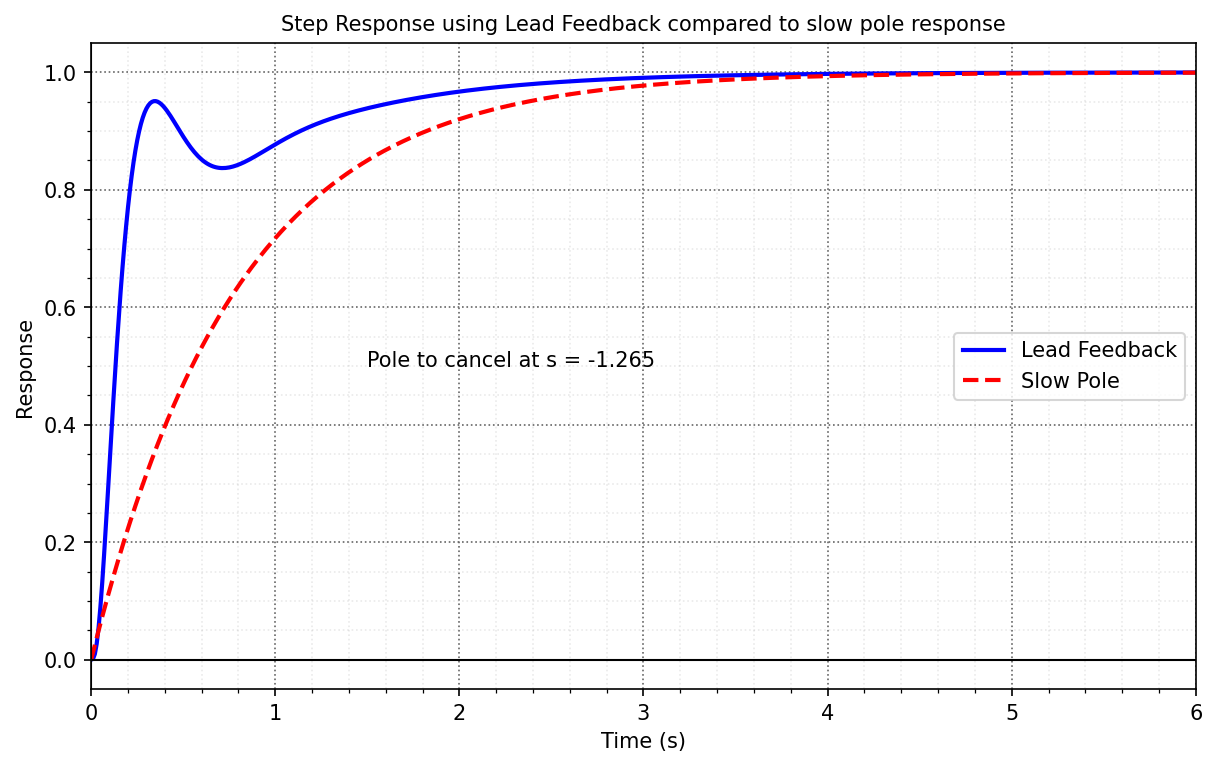

In [11]:
y_lead,t_lead=cmat.step(Gcl_lead,t)

# find real clp poles
pdrr = [x.real for x in scl_lead if np.abs(x.imag) < 1e-3]
# now see which is at low freq that we might want to cancel
s_cancel = max([x for x in pdrr if x < 0])

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t_lead,y_lead,'b',label='Lead Feedback')
plt.plot(t_lead,1-np.exp(s_cancel*t_lead),'r--',label='Slow Pole')
plt.title("Step Response using Lead Feedback compared to slow pole response")
plt.xlim(0,6)
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Response')
bm.nicegrid(ax)

ax.text(0.25, 0.5, "Pole to cancel at s = {:4.3f}".format(s_cancel), transform=ax.transAxes)

plt.savefig("./figs/L11_des2_1a.pdf", dpi=600)
plt.show()

## Add feedforward to architecture

In [12]:
# Add feedforward
def feedback_ff(G,Gc,Kf = 1):
    return G*(ct.tf(Kf,1)+Gc)/(1+G*Gc)

In [13]:
Dc = np.polyval(Gc.den[0][0], s_cancel)
Nc = np.polyval(Gc.num[0][0], s_cancel)
kff = - Nc / Dc
print(f"Analytic: Gain to cancel k = {kff.real:8.6f}")

Analytic: Gain to cancel k = -0.991475


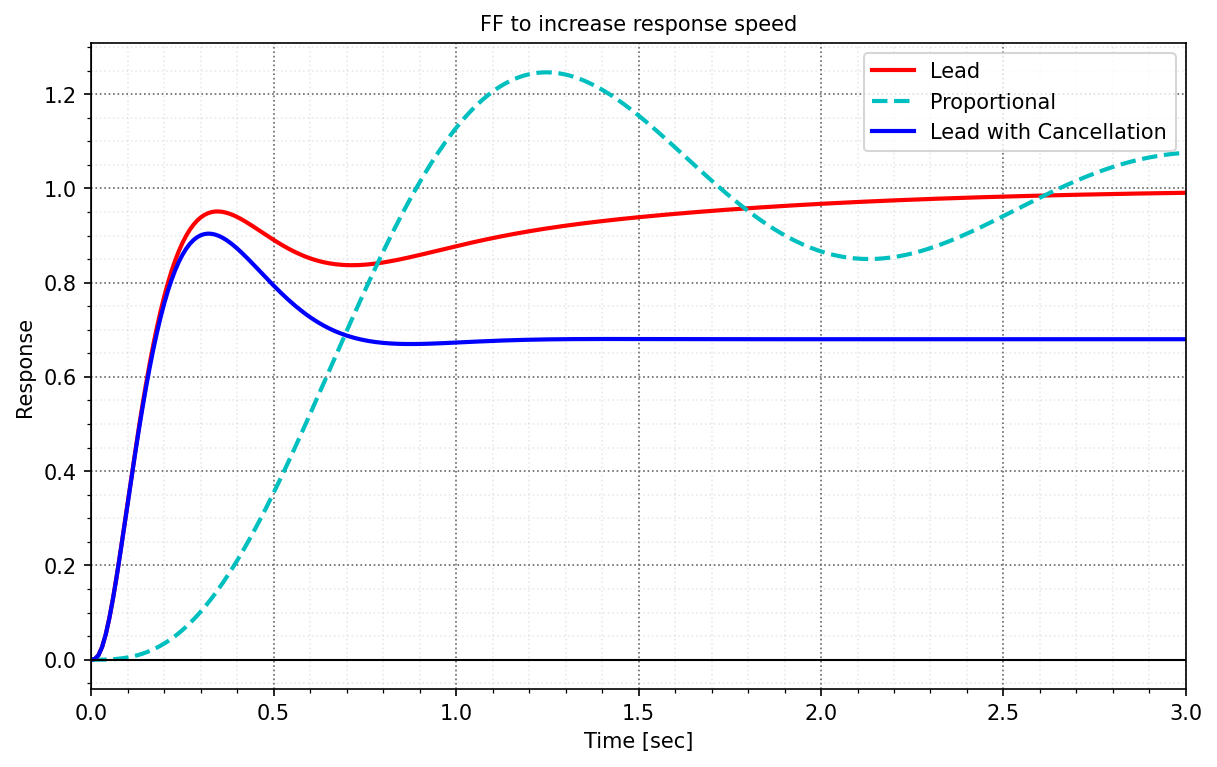

In [14]:
Gcl_cancel = feedback_ff(G,Gc,kff)
y_cancel,t_cancel = cmat.step(Gcl_cancel,t_lead)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax.plot(t_lead,y_lead,'r-',label='Lead')
plt.plot(t,y_proportional,'c--',label='Proportional')
ax.plot(t_cancel,y_cancel,'b-',label='Lead with Cancellation')
bm.nicegrid(ax)
ax.set_xlabel('Time [sec]')
ax.set_ylabel('Response')
ax.set_xlim(0,3)
plt.legend()
plt.title(r"Step Response with Feedforward $K_f = {:4.2f}$".format(kff))
plt.title("FF to increase response speed")
plt.savefig("./figs/L11_des2_2.pdf", dpi=600)
plt.show()

omega_n:	10.396
zeta   :	0.333
Tr     :	0.11s
Ts     :	0.68s
Mp     :	0.33
Tp     :	0.32s
Yss    :	1.00


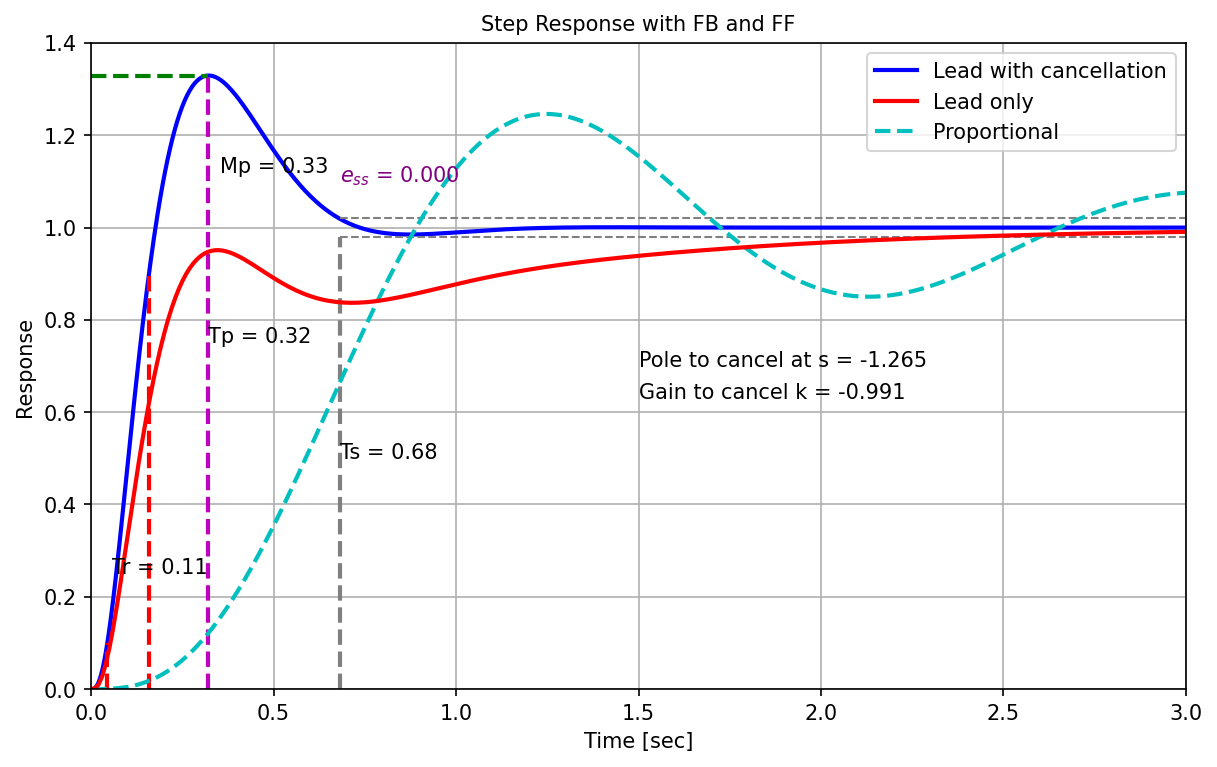

In [15]:
# Improve steady state error using cancellation
K1 = 1/np.abs(np.trim_zeros(Gcl_cancel.num[0][0], 'b')[-1]/np.trim_zeros(Gcl_cancel.den[0][0], 'b')[-1]) # normalize to set step resp to right SS value
Gcl_cancel *= K1
y_lead2,t_lead2=cmat.step(Gcl_cancel,10)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
S_lead2 = cm.Step_info(t_lead2,y_lead2)
S_lead2.printout()
S_lead2.nice_plot(ax,Tmax=3)
plt.plot(t,y_proportional,'c--')
plt.plot(t_lead,y_lead,'r-')
plt.legend(['Lead - cancelled/scaled'])
plt.title("Step Response with FB and FF",loc='center')
ax.set_xlabel('Time [sec]')
ax.set_ylabel('Response')
ax.text(0.5, 0.5, "Pole to cancel at s = {:4.3f}".format(s_cancel), transform=ax.transAxes)
ax.text(0.5, 0.45, "Gain to cancel k = {:4.3f}".format(kff.real), transform=ax.transAxes)

from matplotlib.lines import Line2D
# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-'),
    Line2D([0], [0], color='red', lw=2, linestyle='-'),
    Line2D([0], [0], color='c', lw=2, linestyle='--')
]
# Add legend with custom handles
ax.legend(custom_lines, ['Lead with cancellation', 'Lead only', 'Proportional', ])
plt.savefig("./figs/L11_des2_3.pdf", dpi=600)
plt.show()